# Import Required Modules

In [ ]:
import numpy as np
import pandas as pd

# Zero Shot

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
df = pd.read_excel('Setntiment Analysis Jais Zero Shot.xlsx')

In [ ]:
nor_pre = []
for pr in df['Normalized Sentiment']:
  if "إيجابي" in pr:
    nor_pre.append("Positive")
  elif "سلبي" in pr:
    nor_pre.append("Negative")
  elif "محايد" in pr:
    nor_pre.append("Neutral")
  elif "للأسف، واجه النموذج مشكلة. يرجى مراجعة وتحديث السياق لإزالة أي محتوى غير مناسب." in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك' in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف' in pr:
    nor_pre.append("Unclassified")
  elif 'السؤال طويل جدًا. من فضلك اختصر سؤالك.' in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_zero = nor_pre

In [ ]:
true = pd.read_excel('sampled_sentiment_data.xlsx')
y_true = true['sentiment'].values
print(classification_report(y_true, pred_zero, digits = 4))

              precision    recall  f1-score   support

    Negative     0.6489    0.7305    0.6873       167
     Neutral     0.5930    0.3054    0.4032       167
       Other     0.0000    0.0000    0.0000         0
    Positive     0.6507    0.5689    0.6070       167
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.5349       501
   macro avg     0.3785    0.3210    0.3395       501
weighted avg     0.6309    0.5349    0.5658       501



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


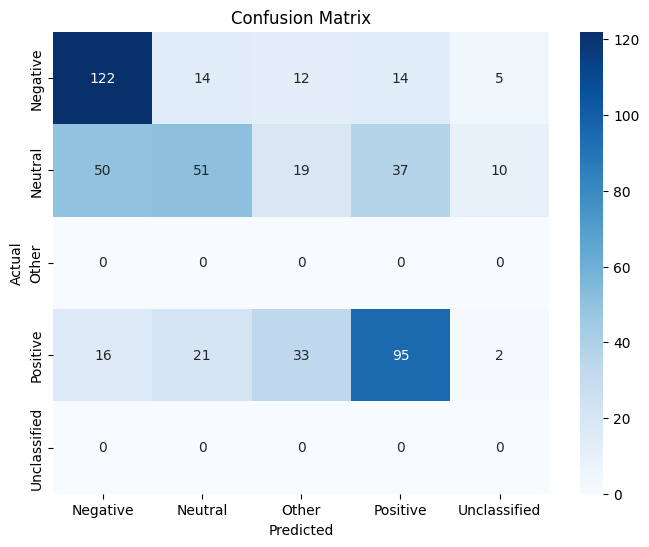

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_zero)
labels = np.unique(pred_zero)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Two Class

In [ ]:
true['pred'] = pred_zero

true.loc[true["pred"] == "Neutral", "pred"] = "Other"

true = true[true['sentiment'] != 'Neutral']
y_true = true['sentiment'].values
y_pred = true['pred'].values
print(classification_report(y_true, y_pred, digits = 4))

              precision    recall  f1-score   support

    Negative     0.8841    0.7305    0.8000       167
       Other     0.0000    0.0000    0.0000         0
    Positive     0.8716    0.5689    0.6884       167
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.6497       334
   macro avg     0.4389    0.3249    0.3721       334
weighted avg     0.8778    0.6497    0.7442       334



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


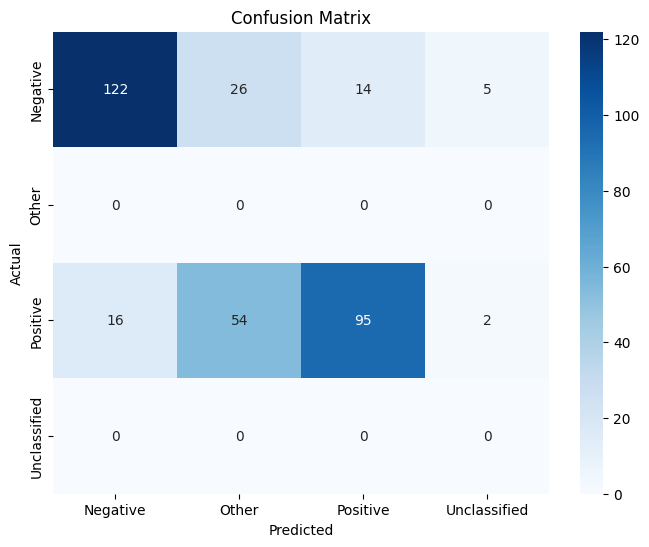

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = np.unique(y_pred)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Fewshot

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
df = pd.read_excel('Sentiment Analysis Jais Few Shot.xlsx')

In [ ]:
nor_pre = []
for pr in df['Normalizad Output']:
  if "إيجابي" in pr:
    nor_pre.append("Positive")
  elif "سلبي" in pr:
    nor_pre.append("Negative")
  elif "محايد" in pr:
    nor_pre.append("Neutral")
  elif "خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك" in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف' in pr:
    nor_pre.append("Unclassified")
  elif 'يبدو أن هناك خطأ مطبعي في سؤالك حيث أنه ليس باللغة الإنجليزية التي يفهمها المساعد الذكي الخاص بي. هل يمكنك إعادة صياغة سؤالك؟' in pr:
    nor_pre.append("Unclassified")
  elif 'يبدو أن هناك خطأ مطبعي في سؤالك حيث أن النص المقدم ليس جملة كاملة وبالتالي يصعب تصنيفه وفقًا لمشاعره. هل يمكنك تقديم جملة كاملة للتحليل العاطفي؟' in pr:
    nor_pre.append("Unclassified")
  elif 'غير محددة' in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_few = nor_pre

In [ ]:
true = pd.read_excel('sampled_sentiment_data.xlsx')
y_true = true['sentiment'].values
print(classification_report(y_true, pred_few, digits = 4))

              precision    recall  f1-score   support

    Negative     0.6054    0.6707    0.6364       167
     Neutral     0.7093    0.3653    0.4822       167
       Other     0.0000    0.0000    0.0000         0
    Positive     0.6485    0.7844    0.7100       167
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.6068       501
   macro avg     0.3926    0.3641    0.3657       501
weighted avg     0.6544    0.6068    0.6095       501



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


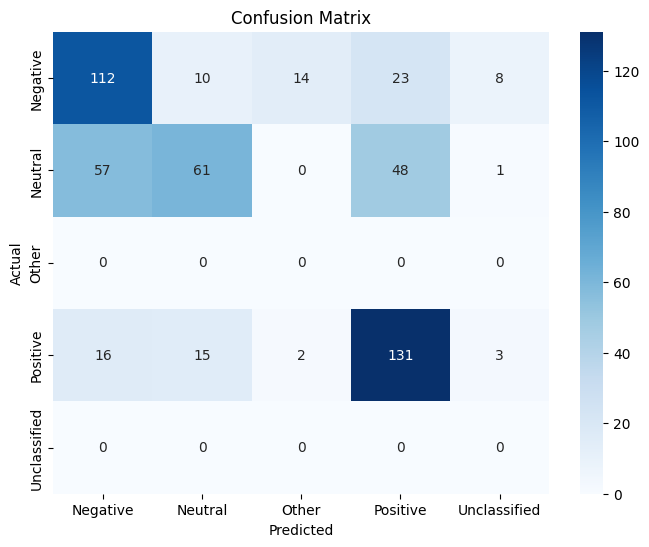

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_few)
labels = np.unique(pred_few)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# CoT

In [ ]:
df = pd.read_excel('Sentiment Analysis Jais CoT.xlsx')

In [ ]:
nor_pre = []
for pr in df['Normalized Output']:
  if "إيجابي" in pr:
    nor_pre.append("Positive")
  elif "سلبي" in pr:
    nor_pre.append("Negative")
  elif "محايد" in pr:
    nor_pre.append("Neutral")
  elif "خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف" in pr:
    nor_pre.append("Unclassified")
  elif "خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك" in pr:
    nor_pre.append("Unclassified")
  elif "التحليل العاطفي لهذه الجملة الخاصة غير قابل للتنفيذ بسبب نقص المعلومات المعنوية والسياق القابل للفهم" in pr:
    nor_pre.append("Unclassified")
  elif "مزيج من الأحرف والرموز المختلفة بدون رسالة واضحة أو سياق" in pr:
    nor_pre.append("Unclassified")
  elif "ليس من الممكن تحليله للمشاعر حيث يفتقد السياق والمعنى الواضح" in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_cot = nor_pre

In [ ]:
from sklearn.metrics import classification_report
true = pd.read_excel('sampled_sentiment_data.xlsx')
y_true = true['sentiment'].values
print(classification_report(y_true, pred_cot, digits = 4))

              precision    recall  f1-score   support

    Negative     0.6928    0.6347    0.6625       167
     Neutral     0.6347    0.6347    0.6347       167
       Other     0.0000    0.0000    0.0000         0
    Positive     0.7655    0.6647    0.7115       167
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.6447       501
   macro avg     0.4186    0.3868    0.4018       501
weighted avg     0.6977    0.6447    0.6696       501



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


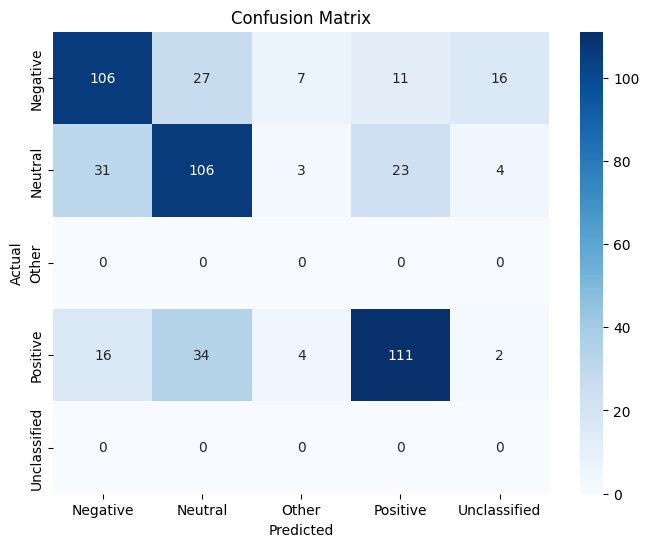

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_cot)
labels = np.unique(pred_cot)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()